Ejercicio 3 — Análisis de patrones de fraude bancario

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.read_csv('ejercicio_3_fraude_bancario.csv')

In [3]:
print("Primeros registros:")
print(df.head())

Primeros registros:
  Transaccion  Monto  Hora Perfil_Real
0          T1    510    13      Normal
1          T2    480    14      Normal
2          T3    550    12      Normal
3          T4    460    15      Normal
4          T5   4500     3  SOSPECHOSA


In [4]:
X = df[['Monto', 'Hora']]
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print("Datos escalados:")
print(X_escalado[:5])

Datos escalados:
[[-0.56339442  0.43608276]
 [-0.57952726  0.59182661]
 [-0.54188398  0.28033892]
 [-0.59028248  0.74757045]
 [ 1.58227253 -1.12135568]]


In [5]:
# 3. Grafico k-distancia
vecinos = NearestNeighbors(n_neighbors=3)
vecinos_fit = vecinos.fit(X_escalado)
distancias, indices = vecinos_fit.kneighbors(X_escalado)
distancias = np.sort(distancias[:, 2])

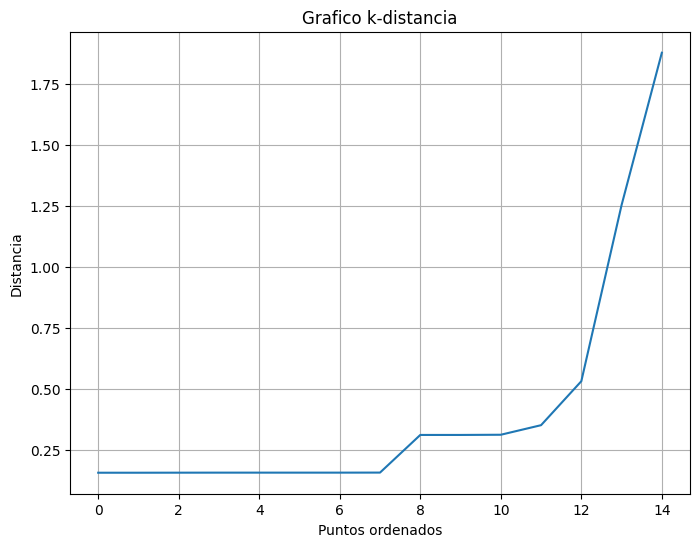

In [6]:
plt.figure(figsize=(8,6))
plt.plot(distancias)
plt.title('Grafico k-distancia')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')
plt.grid(True)
plt.show()

In [7]:
eps_elegido = 0.7

In [8]:
#DBSCAN
modelo = DBSCAN(
    eps=eps_elegido,
    min_samples=3
)
clusters = modelo.fit_predict(X_escalado)

df['Cluster'] = clusters
df['Estado'] = df['Cluster'].apply(
    lambda x: 'Sospechosa' if x == -1 else 'Normal'
)

print("DataFrame con resultados:")
print(df)

DataFrame con resultados:
   Transaccion  Monto  Hora Perfil_Real  Cluster      Estado
0           T1    510    13      Normal        0      Normal
1           T2    480    14      Normal        0      Normal
2           T3    550    12      Normal        0      Normal
3           T4    460    15      Normal        0      Normal
4           T5   4500     3  SOSPECHOSA        1      Normal
5           T6   5000     2  SOSPECHOSA        1      Normal
6           T7   4800     1  SOSPECHOSA        1      Normal
7           T8    520    13      Normal        0      Normal
8           T9    490    14      Normal        0      Normal
9          T10    200    23  SOSPECHOSA       -1  Sospechosa
10         T11    150     0  SOSPECHOSA       -1  Sospechosa
11         T12   4200     4  SOSPECHOSA        1      Normal
12         T13    530    11      Normal        0      Normal
13         T14    470    16      Normal        0      Normal
14         T15    505    12      Normal        0      Norma

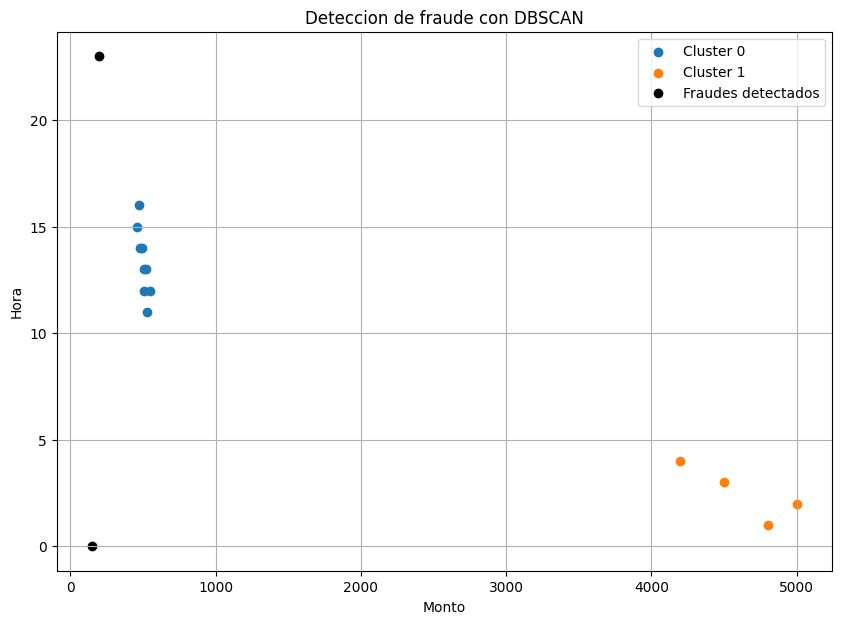

In [9]:
plt.figure(figsize=(10,7))
clusters_unicos = set(clusters)
for cluster in clusters_unicos:
    datos_cluster = df[df['Cluster'] == cluster]
    if cluster == -1:
        plt.scatter(
            datos_cluster['Monto'],
            datos_cluster['Hora'],
            color='black',
            label='Fraudes detectados'
        )
    else:
        plt.scatter(
            datos_cluster['Monto'],
            datos_cluster['Hora'],
            label=f'Cluster {cluster}'
        )

plt.title('Deteccion de fraude con DBSCAN')
plt.xlabel('Monto')
plt.ylabel('Hora')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
total = len(df)
sospechosas = len(df[df['Estado'] == 'Sospechosa'])
porcentaje = (sospechosas / total) * 100

print(f"Total de transacciones: {total}")
print(f"Transacciones sospechosas: {sospechosas}")
print(f"Porcentaje sospechoso: {porcentaje:.2f}%")

Total de transacciones: 15
Transacciones sospechosas: 2
Porcentaje sospechoso: 13.33%


¿Qué ventaja tiene DBSCAN sobre K-Means para detectar fraude?

DBSCAN tiene ventaja porque puede detectar
datos atipicos o ruido automaticamente y marcarlos como sospechosos.

K-Means obliga a que todos los datos pertenezcan
a un cluster, por lo que las transacciones
fraudulentas tambien serian agrupadas como normales.